# **Preprocesamiento y Modelado**
---

## **Módulos utilizados**

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import dalex as dx
import optuna
from optuna.samplers import TPESampler

from utils.utils_visualization import plot_distribution_target, plot_log, ROC_Curve_CM, plot_features_importance
from utils.utils_preprocessing import build_preprocessor
from utils.utils_train import *

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

## **Bloques de contenido**
1. [Introducción](#1-introducción)
2. [Carga de los datos](#2-carga-de-los-datos)
3. [Separación Train / Test](#3-separación-train--test)
4. [Selección de features](#4-selección-de-features)
5. [Pipeline de preprocesado](#5-pipeline-de-preprocesado)
6. [Baseline - Regresión Logística](#6-baseline---regresión-logística)
7. [Validación cruzada - Comparativa de modelos](#7-validación-cruzada---comparativa-de-modelos)
8. [Informe de clasificación y AUC](#8-informe-de-clasificación-y-auc)
9. [Feature Importance](#9-feature-importance)
10. [Optimización con Optuna](#10-optimización-con-optuna)
11. [Explicabilidad con DALEX](#11-explicabilidad-con-dalex)
12. [Resumen y conclusiones](#12-resumen-y-conclusiones)

## 1. **Introducción**

En este notebook se lleva a cabo el **preprocesamiento y modelado** del problema de predicción de recompra de clientes.

El objetivo es construir modelos capaces de predecir la **probabilidad de que un cliente repita compra**. Esta variable objetivo se creó sobre la base de sus métricas de comportamiento (RFM y derivadas) calculadas en el período de observación, en el Notebook 01 de este proyecto.

### **Punto de partida**

Del EDA se extraen las siguientes conclusiones relevantes para esta fase:
- El dataset de modelado (`df_rfm`) cuenta con **5.281 clientes**, sin nulos.
- La variable objetivo `target`, sobre el dataset oroginal sin agrupación por cliente, presentaba **desbalanceo**. Se observará cómo es esa distribución por cliente.
- Se excluye `avg_basket` (no significativa en el test de Mann-Whitney) y `n_countries` (baja cardinalidad, poca varianza).
- Variables como `frequency`, `monetary`, `avg_basket` y `n_products` presentan **fuerte asimetría positiva** y outliers → se aplicará transformación logarítmica.
- Se detecta multicolinealidad entre `recency` y `avg_days_between_orders` (r=0.82): se gestionará con regularización o selección explícita.

### **Métrica principal: AUC-ROC**

Dado a la naturaleza del problema (estimación de **probabilidad** y clasificación binaria), la métrica principal será el **AUC-ROC** (*Area Under the ROC Curve*):

- Mide la **capacidad discriminante** del modelo con independencia del umbral de decisión.
- Permite ordenar clientes por riesgo/oportunidad, directamente accionable para los equipos de fidelización y retención.

Como métricas complementarias se reportarán **Precision, Recall y F1-score** en el informe de clasificación, así como la **matriz de confusión**, para evaluar el comportamiento real del modelo con el umbral por defecto (0.5).

### **Flujo del notebook**

```
df_rfm  →  Train/Test Split  →  Selección de features
        →  Pipeline (log-transform + StandardScaler)
        →  Baseline (Regresión Logística)
        →  Validación cruzada (LR / RF / XGBoost / LGBM)
        →  Mejor modelo: informe + AUC + Feature Importance
        →  Explicabilidad con DALEX
        →  [Notebook 4] Optimización con Optuna
```

## 2. **Carga de los datos**

In [2]:
df_rfm = pd.read_csv('./data/clean/online_retail_unique.csv', index_col=False)
df_rfm.head()

,customer_id,recency,frequency,monetary,avg_basket,n_products,n_countries,customer_age_days,avg_days_between_orders,target
0,12346,234,12,77556.4600,2281.0724,27,1,634,57.6364,0
1,12347,38,6,3402.3900,20.7463,107,1,312,62.4000,1
2,12348,157,4,1709.4000,35.6125,25,1,346,115.3333,1
3,12349,316,3,2671.1400,26.1876,90,1,497,248.5000,1
4,12350,218,1,334.4000,19.6706,17,1,218,218.0000,0


In [3]:
# Distribución del target
print(df_rfm['target'].value_counts())
print()
print('Proporción:')
print(df_rfm['target'].value_counts(normalize=True).round(4))

target
0    2985
1    2294
Name: count, dtype: int64

Proporción:
target
0   0.5654
1   0.4346
Name: proportion, dtype: float64


Se observa que, agrupándolo por cliente, ese balanceo se estabiliza teniendo proporciones similares para ambas clases.

## 3. **Separación Train / Test**

Se utiliza una división **80 / 20** con estratificación sobre el `target` para preservar la proporción de clases en ambos conjuntos. El conjunto de test **no se toca durante el entrenamiento ni la validación cruzada**; únicamente se emplea para la evaluación final del modelo seleccionado.

In [4]:
X = df_rfm.drop(columns=['target', 'customer_id'])
y = df_rfm['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

print(f'Train: {X_train.shape[0]} filas  |  Test: {X_test.shape[0]} filas')
print()
print('Distribución target en Train:')
print(y_train.value_counts(normalize=True).round(4))
print()
print('Distribución target en Test:')
print(y_test.value_counts(normalize=True).round(4))

Train: 4223 filas  |  Test: 1056 filas

Distribución target en Train:
target
0   0.5655
1   0.4345
Name: proportion, dtype: float64

Distribución target en Test:
target
0   0.5653
1   0.4347
Name: proportion, dtype: float64


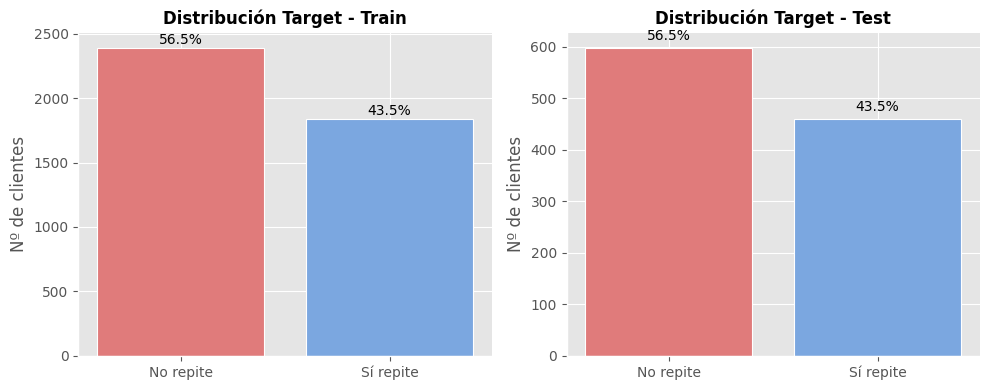

In [5]:
plot_distribution_target(y_train, y_test)

## 4. **Selección de features**

A partir de los resultados del EDA se definen dos conjuntos de features para comparar rendimiento:

| Conjunto | Features incluidas | Criterio |
|---|---|---|
| **`features_selected`** | Significativas en contraste de hipótesis (Mann-Whitney p<0.05) + `n_countries` | Selección estadística |
| **`features_all`** | Todas las features del `df_rfm` (excl. `customer_id`) | Baseline completo |

Se excluye `avg_basket` del conjunto seleccionado por no superar el test de Mann-Whitney (p > 0.05).

In [6]:
# Features seleccionadas por el EDA (significativas estadísticamente)
features_selected = [
    'avg_days_between_orders',
    'recency',
    'frequency',
    'monetary',
    'n_products',
    'customer_age_days',
    'n_countries'      
]

# Todas las features disponibles
features_all = [col for col in X.columns]

print('Features seleccionadas:', features_selected)
print()
print('Todas las features:', features_all)

Features seleccionadas: ['avg_days_between_orders', 'recency', 'frequency', 'monetary', 'n_products', 'customer_age_days', 'n_countries']

Todas las features: ['recency', 'frequency', 'monetary', 'avg_basket', 'n_products', 'n_countries', 'customer_age_days', 'avg_days_between_orders']


## 5. **Pipeline de preprocesado**

### 5.1 **Análisis de la transformación logarítmica**

Del EDA sabemos que `frequency`, `monetary`, `avg_basket` y `n_products` presentan **fuerte asimetría positiva** (skewness > 6) y abundantes outliers. La transformación logarítmica `log1p(x)` (= log(1+x), válida para valores ≥ 0) reduce la asimetría, comprime los outliers y mejora el comportamiento de modelos sensibles a la escala como la Regresión Logística.

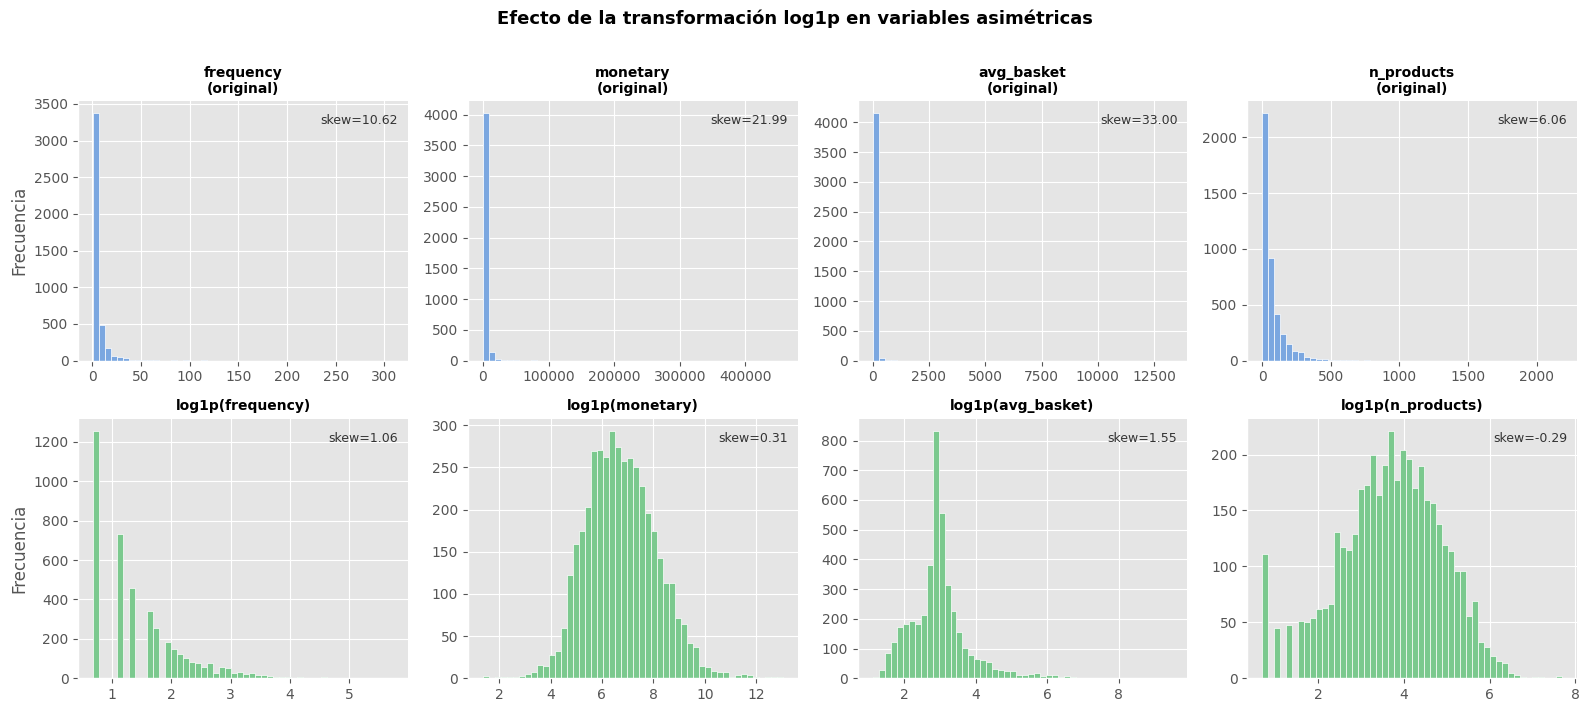

In [7]:
cols_log = ['frequency', 'monetary', 'avg_basket', 'n_products']

plot_log(cols_log, X_train)

*Observaciones*: La transformación `log1p` reduce notablemente la asimetría en las cuatro variables. Las distribuciones resultantes son más simétricas y compactas, lo que beneficia especialmente a los modelos lineales.

### 5.2 **Definición del ColumnTransformer y pipelines**

Se define un `ColumnTransformer` con dos ramas:
- **Rama log + escala**: para las variables asimétricas → `log1p` → `StandardScaler`
- **Rama escala**: para el resto de variables numéricas → `StandardScaler`

Se construyen **dos pipelines** (features seleccionadas vs. todas las features) para facilitar la comparación.

In [8]:
cols_log_transform = ['frequency', 'monetary', 'avg_basket', 'n_products']

preprocessor_sel = build_preprocessor(features_selected, cols_log_transform)
preprocessor_all = build_preprocessor(features_all, cols_log_transform)

In [9]:
preprocessor_sel

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('log_scale', ...), ('scale', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

In [10]:
preprocessor_all

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('log_scale', ...), ('scale', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

## 6. **Baseline - Regresión Logística**

Se entrena una Regresión Logística como modelo de referencia, tanto con las **features seleccionadas** como con **todas las features**. El objetivo es establecer un punto de comparación sencillo e interpretable antes de pasar a modelos más complejos.

In [11]:
lr_params = dict(max_iter=1000, random_state=42) # Se ajusta hiperparámetros simples

# Pipeline baseline de las features seleccionadas
pipe_lr_sel = Pipeline([
    ('preprocessor', preprocessor_sel),
    ('model', LogisticRegression(**lr_params))
])

# Pipeline baseline de todas las features
pipe_lr_all = Pipeline([
    ('preprocessor', preprocessor_all),
    ('model', LogisticRegression(**lr_params))
])

# Entrenamiento
pipe_lr_sel.fit(X_train[features_selected], y_train)
pipe_lr_all.fit(X_train[features_all], y_train)

# Predicciones de probabilidad sobre train y test
for name, pipe, feats in [
    ('Baseline (LR) - Sel.', pipe_lr_sel, features_selected),
    ('Baseline (LR) - All',  pipe_lr_all, features_all)
]:
    auc_train = roc_auc_score(y_train, pipe.predict_proba(X_train[feats])[:, 1])
    auc_test  = roc_auc_score(y_test,  pipe.predict_proba(X_test[feats])[:, 1])
    print(f'{name} AUC Train: {auc_train:.4f}  |  AUC Test: {auc_test:.4f}')

Baseline (LR) - Sel. AUC Train: 0.7972  |  AUC Test: 0.8075
Baseline (LR) - All AUC Train: 0.7975  |  AUC Test: 0.8086


***Observaciones***

Muy buenos resultados para un baseline lineal.

- AUC de 0.80 con una Regresión Logística simple es un punto de partida muy sólido.
- No hay sobreajuste: Train y Test están prácticamente igualados, lo que indica que el modelo generaliza bien y el pipeline de preprocesado es correcto.
- La diferencia entre features seleccionadas y todas es mínima, lo que confirma que `avg_basket` y `n_countries` aportan muy poco, por lo que la selección del EDA fue acertada.

### 6.1. **Curva ROC - Basiline de Regresión Logística**

CURVA ROC CON TEST - BASELINE LR
--------------------------------
Con Features seleccionadas


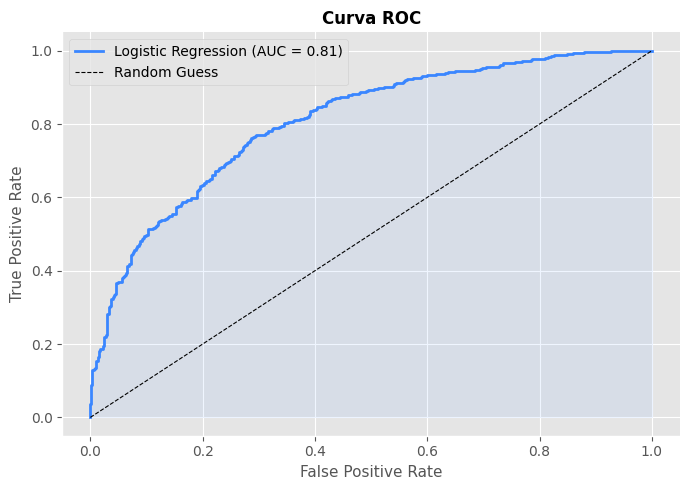

In [12]:
auc_test  = roc_auc_score(y_test, pipe_lr_sel.predict_proba(X_test[features_selected])[:, 1])

print('CURVA ROC CON TEST - BASELINE LR')
print('--------------------------------')
print('Con Features seleccionadas')

ROC_Curve_CM(y_test, pipe_lr_sel.predict_proba(X_test[features_selected])[:, 1], auc_test, model_name='Logistic Regression')

## 7. **Validación cruzada - Comparativa de modelos**

Se evalúan cuatro modelos con validación cruzada estratificada de **5 folds** sobre el conjunto de entrenamiento:

| Modelo | Justificación |
|---|---|
| Regresión Logística | Baseline interpretable, robusto con regularización |
| Random Forest | Ensemble robusto, maneja bien outliers y no linealidades |
| XGBoost | GBDT eficiente, buen rendimiento out-of-the-box |
| LightGBM | GBDT más rápido, especialmente en datasets medianos |

Para cada modelo se evalúan las dos versiones (features seleccionadas vs. todas).

In [13]:
models = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
    'RandomForest':       RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'XGBoost':            XGBClassifier(n_estimators=200, random_state=42, eval_metric='logloss', verbosity=0),
    'LightGBM':           LGBMClassifier(n_estimators=200, random_state=42, verbose=-1)
}
configs_prepro = [('selected', preprocessor_sel, features_selected),
                  ('all',      preprocessor_all, features_all)]

df_results = cv_evaluate(X, y, models, configs_prepro)

LogisticRegression     [selected] AUC: 0.7982
LogisticRegression     [all     ] AUC: 0.7985
RandomForest           [selected] AUC: 0.7848
RandomForest           [all     ] AUC: 0.7867
XGBoost                [selected] AUC: 0.7698
XGBoost                [all     ] AUC: 0.7707
LightGBM               [selected] AUC: 0.7782
LightGBM               [all     ] AUC: 0.7804


***Observaciones***: 

- La **Regresión Logística** es el mejor modelo, con un *AUC de 0.798*, superando a modelos más complejos como Random Forest, XGBoost o LightGBM. Esto indica que, con el tamaño del dataset y las features disponibles, las relaciones entre las variables RFM y la probabilidad de recompra son suficientemente lineales como para que un modelo simple y bien preprocesado sea la opción más eficaz.

- Las **features seleccionadas** son suficientes. La diferencia de rendimiento entre usar todas las variables o solo las seleccionadas estadísticamente en el EDA es prácticamente nula en todos los modelos. Esto valida la decisión de excluir `avg_basket` y simplifica el modelo final.

- El **modelo generaliza correctamente**. El AUC obtenido en validación cruzada (0.798) es consistente con el AUC del baseline sobre el conjunto de test (0.81), sin señales de sobreajuste.

- Existe margen de mejora en la detección de clientes fieles. El **Recall** (0.65) indica que aproximadamente 1 de cada 3 clientes que sí van a repetir compra no está siendo identificado correctamente. Este será el principal foco de la fase de **optimización con Optuna**.

## 8. **Informe de clasificación y AUC**

Se selecciona el mejor modelo de la comparativa anterior y se evalúa sobre el **conjunto de test**.

In [14]:
BEST_MODEL_NAME = 'LogisticRegression'
BEST_FEAT_SET = 'selected'
BEST_FEATS = features_selected 
BEST_PREPROCESSOR = preprocessor_sel

In [15]:
best_model_instance = clone(models[BEST_MODEL_NAME])

best_pipe = Pipeline([
    ('preprocessor', clone(BEST_PREPROCESSOR)),
    ('model', best_model_instance)
])

best_pipe.fit(X_train[BEST_FEATS], y_train)

y_pred= best_pipe.predict(X_test[BEST_FEATS])
y_pred_proba = best_pipe.predict_proba(X_test[BEST_FEATS])[:, 1]

auc_final = roc_auc_score(y_test, y_pred_proba)
print(f'AUC-ROC en Test: {auc_final:.4f}')
print()
print('Informe de clasificación:')
print(classification_report(y_test, y_pred, target_names=['No repite (0)', 'Sí repite (1)']))

AUC-ROC en Test: 0.8075

Informe de clasificación:
               precision    recall  f1-score   support

No repite (0)       0.75      0.79      0.77       597
Sí repite (1)       0.70      0.65      0.67       459

     accuracy                           0.73      1056
    macro avg       0.72      0.72      0.72      1056
 weighted avg       0.73      0.73      0.73      1056



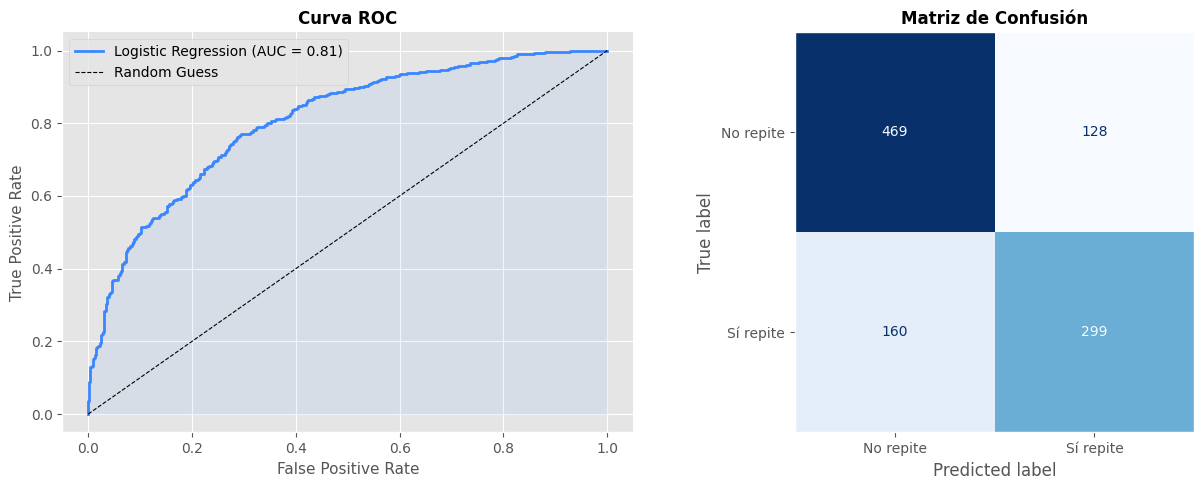

In [16]:
ROC_Curve_CM(y_test, y_pred_proba, auc_test, model_name='Logistic Regression', y_pred=y_pred)

***Observaciones***: 

- El modelo alcanza un **AUC de 0.81**, lo que indica una buena capacidad para distinguir entre clientes que repetirán compra y los que no, siendo consistente con los resultados de la validación cruzada (sin sobreajuste).

- En cuanto al **informe de clasificación**, el modelo se comporta de forma ligeramente asimétrica según la clase:
    - Detecta mejor a los clientes que no van a repetir (*F1=0.77*): de 597 clientes reales, acierta 469 y solo falla en 128.
    - Es algo menos preciso con los clientes que sí van a repetir (*F1=0.67*): de 459 clientes reales, deja escapar 160, es decir, casi 1 de cada 3 clientes fidelizables no es detectado.

El principal punto de **mejora de cara a Optuna** es reducir esos 160 falsos negativos (clientes que sí repetirían pero el modelo clasifica como perdidos), ya que representan oportunidades de fidelización desaprovechadas. Esto se puede abordar ajustando el umbral de decisión o penalizando más los errores en la clase positiva.

## 9. **Feature Importance**

Se analiza la importancia de cada variable en el mejor modelo para entender qué información está utilizando para hacer sus predicciones. El resultado también sirve de guía para el proceso de optimización con Optuna.

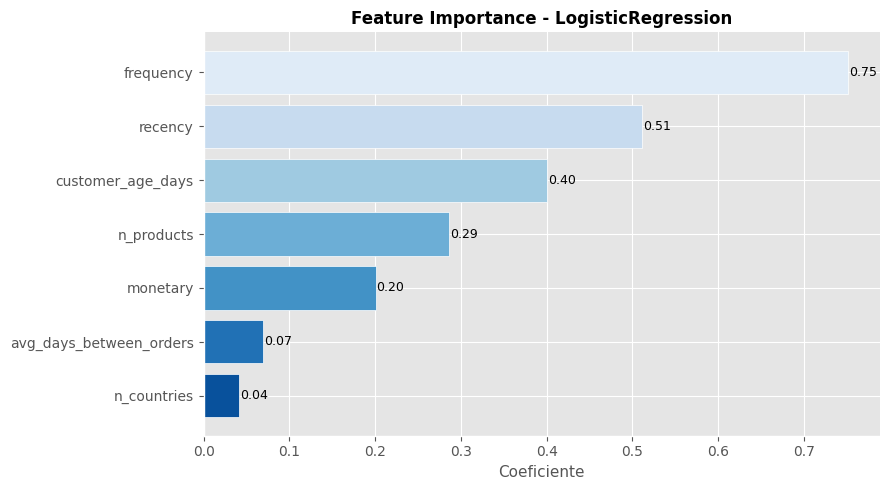

In [17]:
fitted_model = best_pipe.named_steps['model']
fitted_prep  = best_pipe.named_steps['preprocessor']

df_importance = plot_features_importance(fitted_model, fitted_prep, BEST_MODEL_NAME)

In [18]:
df_importance

,Feature,Importance
0,frequency,0.7510
1,recency,0.5111
2,customer_age_days,0.4002
3,n_products,0.2859
4,monetary,0.2004
5,avg_days_between_orders,0.0697
6,n_countries,0.0417


In [19]:
# Se guarda el ranking
top_features = df_importance['Feature'].tolist()
print('Ranking de features por importancia:')
for i, feat in enumerate(top_features, 1):
    print(f'  {i}. {feat}')

Ranking de features por importancia:
  1. frequency
  2. recency
  3. customer_age_days
  4. n_products
  5. monetary
  6. avg_days_between_orders
  7. n_countries


## 10. **Optimización con Optuna**

Se optimizan los **tres mejores modelos** de la validación cruzada (Logistic Regression, Random Forest, LightGBM) mediante búsqueda bayesiana con **Optuna**.

Para cada modelo se realizan **100 trials** con validación cruzada `StratifiedKFold(5)` sobre train, usando **AUC-ROC** como métrica de optimización.

Al final se comparan los resultados antes/después de la optimización sobre el conjunto de test.

In [20]:
# Colores del proyecto
C_BLUE  = '#3A86FF'
C_LBLUE = '#7BA7E0'
C_GREEN = '#7BC98E'
C_GRAY  = '#AAAAAA'

### 10.1. **Logistic Regression**

In [21]:
study_lr = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
study_lr.optimize(
    lambda trial: objective(
        trial, 
        x_train=X_train,
        y_train=y_train,
        best_preprocessor=BEST_PREPROCESSOR,
        best_feats=BEST_FEATS,
        model_class=LogisticRegression), 
    n_trials=100, show_progress_bar=False)

print(f'Mejor AUC CV (LR) - {name}:  {study_lr.best_value:.4f}')
print(f'Mejores params (LR) - {name}: {study_lr.best_params}')

[I 2026-03-29 07:18:28,093] A new study created in memory with name: no-name-a42a079a-2810-49a7-9773-d6ad8e8a306e
[I 2026-03-29 07:18:28,223] Trial 0 finished with value: 0.7947899167336315 and parameters: {'C': 0.03148911647956861, 'penalty': 'l1', 'class_weight': None}. Best is trial 0 with value: 0.7947899167336315.
[I 2026-03-29 07:18:28,300] Trial 1 finished with value: 0.7952453806309079 and parameters: {'C': 0.004207053950287938, 'penalty': 'l2', 'class_weight': 'balanced'}. Best is trial 1 with value: 0.7952453806309079.
[I 2026-03-29 07:18:28,366] Trial 2 finished with value: 0.5 and parameters: {'C': 0.0012087541473056963, 'penalty': 'l1', 'class_weight': None}. Best is trial 1 with value: 0.7952453806309079.
[I 2026-03-29 07:18:28,442] Trial 3 finished with value: 0.7953103007638714 and parameters: {'C': 0.00541524411940254, 'penalty': 'l2', 'class_weight': None}. Best is trial 3 with value: 0.7953103007638714.
[I 2026-03-29 07:18:28,519] Trial 4 finished with value: 0.79488

Mejor AUC CV (LR) - Baseline (LR) - All:  0.7957
Mejores params (LR) - Baseline (LR) - All: {'C': 0.014960075237541302, 'penalty': 'l2', 'class_weight': None}


In [22]:
# Entrenamos el LR optimizado sobre todo el train y evaluamos en test
bp_lr = study_lr.best_params
solver_opt = 'liblinear' if bp_lr['penalty'] == 'l1' else 'lbfgs'

lr_opt = LogisticRegression(
    C=bp_lr['C'], penalty=bp_lr['penalty'], solver=solver_opt,
    class_weight=bp_lr['class_weight'], max_iter=1000, random_state=42
)
pipe_lr_opt = Pipeline([('preprocessor', clone(BEST_PREPROCESSOR)),
                        ('model', lr_opt)])
pipe_lr_opt.fit(X_train[BEST_FEATS], y_train)

y_prob_lr_opt  = pipe_lr_opt.predict_proba(X_test[BEST_FEATS])[:, 1]
auc_lr_opt     = roc_auc_score(y_test, y_prob_lr_opt)
print(f'AUC Test LR optimizado: {auc_lr_opt:.4f}')

AUC Test LR optimizado: 0.8069


### 10.2 **Random Forest**

In [23]:
study_rf = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
study_rf.optimize(
    lambda trial: objective(
        trial, 
        x_train=X_train,
        y_train=y_train,
        best_preprocessor=BEST_PREPROCESSOR,
        best_feats=BEST_FEATS,
        model_class=RandomForestClassifier), 
    n_trials=100, show_progress_bar=False)
print(f'Mejor AUC CV (RF):  {study_rf.best_value:.4f}')
print(f'Mejores params (RF): {study_rf.best_params}')


[I 2026-03-29 07:18:37,529] A new study created in memory with name: no-name-1a5c00a7-4174-4bcc-81b1-7364b87887b0
[I 2026-03-29 07:18:40,099] Trial 0 finished with value: 0.7997767088733576 and parameters: {'n_estimators': 287, 'max_depth': 20, 'min_samples_leaf': 15, 'max_features': 'sqrt', 'class_weight': 'balanced'}. Best is trial 0 with value: 0.7997767088733576.
[I 2026-03-29 07:18:44,116] Trial 1 finished with value: 0.7856291582364545 and parameters: {'n_estimators': 401, 'max_depth': 15, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'class_weight': 'balanced'}. Best is trial 0 with value: 0.7997767088733576.
[I 2026-03-29 07:18:46,298] Trial 2 finished with value: 0.7995068440882609 and parameters: {'n_estimators': 252, 'max_depth': 12, 'min_samples_leaf': 9, 'max_features': 'log2', 'class_weight': 'balanced'}. Best is trial 0 with value: 0.7997767088733576.
[I 2026-03-29 07:18:49,608] Trial 3 finished with value: 0.7943292089378307 and parameters: {'n_estimators': 328, 'max_d

Mejor AUC CV (RF):  0.8011
Mejores params (RF): {'n_estimators': 293, 'max_depth': 8, 'min_samples_leaf': 18, 'max_features': 'sqrt', 'class_weight': 'balanced'}


In [24]:
bp_rf = study_rf.best_params

rf_opt = RandomForestClassifier(
    n_estimators=bp_rf['n_estimators'],
    max_depth=bp_rf['max_depth'],
    min_samples_leaf=bp_rf['min_samples_leaf'],
    max_features=bp_rf['max_features'],
    class_weight=bp_rf['class_weight'],
    random_state=42, n_jobs=-1
)
pipe_rf_opt = Pipeline([('preprocessor', clone(preprocessor_sel)),
                        ('model', rf_opt)])
pipe_rf_opt.fit(X_train[BEST_FEATS], y_train)

y_prob_rf_opt = pipe_rf_opt.predict_proba(X_test[BEST_FEATS])[:, 1]
auc_rf_opt    = roc_auc_score(y_test, y_prob_rf_opt)
print(f'AUC Test RF optimizado: {auc_rf_opt:.4f}')


AUC Test RF optimizado: 0.8051


### 10.3 **LightGBM**

In [25]:
study_lgbm = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
study_lgbm.optimize(
    lambda trial: objective(
        trial, 
        x_train=X_train,
        y_train=y_train,
        best_preprocessor=BEST_PREPROCESSOR,
        best_feats=BEST_FEATS,
        model_class=LGBMClassifier), 
    n_trials=100, show_progress_bar=False)
print(f'Mejor AUC CV (LGBM):  {study_lgbm.best_value:.4f}')
print(f'Mejores params (LGBM): {study_lgbm.best_params}')

[I 2026-03-29 07:23:17,372] A new study created in memory with name: no-name-4cc2dabc-c970-46f0-803a-5772830fdde8
[I 2026-03-29 07:23:21,853] Trial 0 finished with value: 0.7539844391015953 and parameters: {'n_estimators': 287, 'learning_rate': 0.2536999076681772, 'max_depth': 10, 'num_leaves': 98, 'min_child_samples': 24, 'class_weight': None}. Best is trial 0 with value: 0.7539844391015953.
[I 2026-03-29 07:23:26,153] Trial 1 finished with value: 0.7736269070408562 and parameters: {'n_estimators': 533, 'learning_rate': 0.07725378389307355, 'max_depth': 10, 'num_leaves': 22, 'min_child_samples': 98, 'class_weight': None}. Best is trial 1 with value: 0.7736269070408562.
[I 2026-03-29 07:23:29,811] Trial 2 finished with value: 0.7983453958535103 and parameters: {'n_estimators': 191, 'learning_rate': 0.018659959624904916, 'max_depth': 6, 'num_leaves': 88, 'min_child_samples': 49, 'class_weight': 'balanced'}. Best is trial 2 with value: 0.7983453958535103.
[I 2026-03-29 07:23:33,282] Tria

Mejor AUC CV (LGBM):  0.8012
Mejores params (LGBM): {'n_estimators': 277, 'learning_rate': 0.011142149223234737, 'max_depth': 5, 'num_leaves': 101, 'min_child_samples': 96, 'class_weight': None}


In [26]:
bp_lgbm = study_lgbm.best_params

lgbm_opt = LGBMClassifier(
    n_estimators=bp_lgbm['n_estimators'],
    learning_rate=bp_lgbm['learning_rate'],
    max_depth=bp_lgbm['max_depth'],
    num_leaves=bp_lgbm['num_leaves'],
    min_child_samples=bp_lgbm['min_child_samples'],
    class_weight=bp_lgbm['class_weight'],
    random_state=42, verbose=-1, n_jobs=-1
)
pipe_lgbm_opt = Pipeline([('preprocessor', clone(preprocessor_sel)),
                           ('model', lgbm_opt)])
pipe_lgbm_opt.fit(X_train[BEST_FEATS], y_train)

y_prob_lgbm_opt = pipe_lgbm_opt.predict_proba(X_test[BEST_FEATS])[:, 1]
auc_lgbm_opt    = roc_auc_score(y_test, y_prob_lgbm_opt)
print(f'AUC Test LGBM optimizado: {auc_lgbm_opt:.4f}')

AUC Test LGBM optimizado: 0.8103


### 10.4 **Comparativa antes / después de Optuna**

In [27]:
# AUC CV baseline (de df_results)
auc_cv_lr_base   = df_results.loc[df_results['Modelo'] == 'LogisticRegression', 'ROC_AUC'].values[0]
auc_cv_rf_base   = df_results.loc[df_results['Modelo'] == 'RandomForest',       'ROC_AUC'].values[0]
auc_cv_lgbm_base = df_results.loc[df_results['Modelo'] == 'LightGBM',           'ROC_AUC'].values[0]

# AUC Test baseline (se recomputa con el best_pipe ya entrenado)
auc_test_lr_base   = roc_auc_score(y_test, best_pipe.predict_proba(X_test[BEST_FEATS])[:, 1])

pipe_rf_base = Pipeline([('preprocessor', clone(preprocessor_sel)),
                          ('model', RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1))])
pipe_rf_base.fit(X_train[BEST_FEATS], y_train)
auc_test_rf_base = roc_auc_score(y_test, pipe_rf_base.predict_proba(X_test[BEST_FEATS])[:, 1])

pipe_lgbm_base = Pipeline([('preprocessor', clone(preprocessor_sel)),
                             ('model', LGBMClassifier(n_estimators=200, random_state=42, verbose=-1))])
pipe_lgbm_base.fit(X_train[BEST_FEATS], y_train)
auc_test_lgbm_base = roc_auc_score(y_test, pipe_lgbm_base.predict_proba(X_test[BEST_FEATS])[:, 1])

# Tabla comparativa
df_comparison = pd.DataFrame({
    'Modelo':        ['LogisticRegression', 'RandomForest', 'LightGBM'],
    'AUC_CV_base':   [auc_cv_lr_base,       auc_cv_rf_base,   auc_cv_lgbm_base],
    'AUC_CV_optuna': [study_lr.best_value,  study_rf.best_value, study_lgbm.best_value],
    'AUC_Test_base': [auc_test_lr_base,     auc_test_rf_base,    auc_test_lgbm_base],
    'AUC_Test_opt':  [auc_lr_opt,           auc_rf_opt,          auc_lgbm_opt],
})
df_comparison['Delta_CV']   = df_comparison['AUC_CV_optuna'] - df_comparison['AUC_CV_base']
df_comparison['Delta_Test'] = df_comparison['AUC_Test_opt']  - df_comparison['AUC_Test_base']

df_comparison

,Modelo,AUC_CV_base,AUC_CV_optuna,AUC_Test_base,AUC_Test_opt,Delta_CV,Delta_Test
0,LogisticRegression,0.7985,0.7957,0.8075,0.8069,-0.0028,-0.0005
1,RandomForest,0.7867,0.8011,0.7789,0.8051,0.0144,0.0262
2,LightGBM,0.7804,0.8012,0.7804,0.8103,0.0208,0.0300


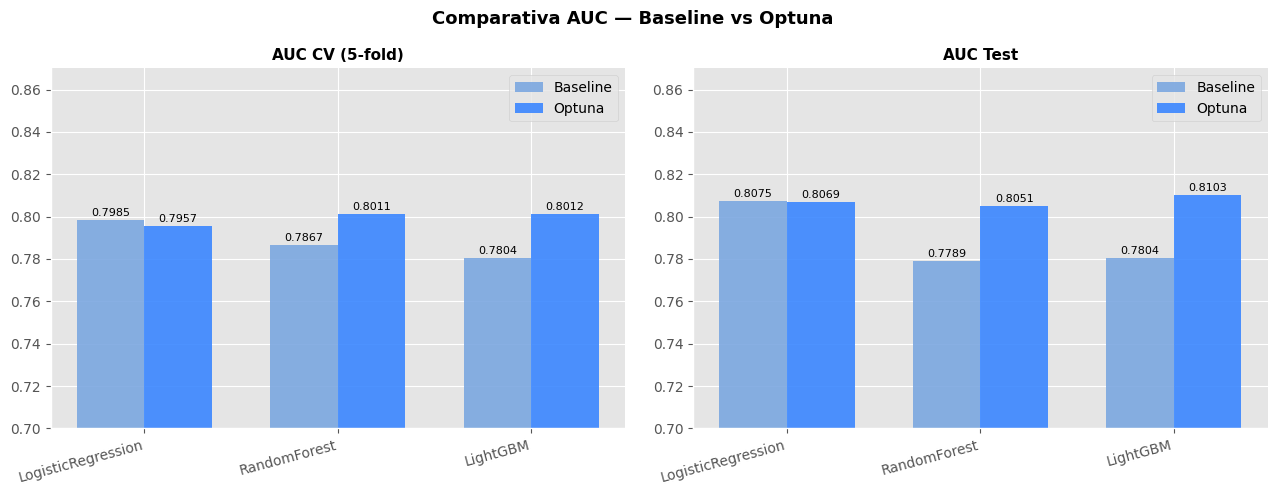

In [30]:
# Gráfico comparativo
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
modelos = df_comparison['Modelo']
x = np.arange(len(modelos))
w = 0.35

for ax, col_base, col_opt, title in zip(
        axes,
        ['AUC_CV_base', 'AUC_Test_base'],
        ['AUC_CV_optuna', 'AUC_Test_opt'],
        ['AUC CV (5-fold)', 'AUC Test']):

    bars1 = ax.bar(x - w/2, df_comparison[col_base],  w, label='Baseline', color=C_LBLUE, alpha=0.9)
    bars2 = ax.bar(x + w/2, df_comparison[col_opt],   w, label='Optuna',   color=C_BLUE,  alpha=0.9)

    for bar in bars1:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=8)
    for bar in bars2:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=8)

    ax.set_xticks(x)
    ax.set_xticklabels(modelos, rotation=15, ha='right')
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_ylim(0.70, 0.87)
    ax.legend()
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('Comparativa AUC — Baseline vs Optuna', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


***Conclusiones***

Tras evaluar el rendimiento de tres algoritmos mediante validación cruzada (CV) y optimización de hiperparámetros con Optuna, se ha seleccionado **`LightGBM`** como el modelo definitivo por las siguientes razones:

- **Rendimiento superior**: Alcanzó el AUC más alto (0.8103) en el conjunto de test, demostrando la mejor capacidad para distinguir entre clientes que recomprarán y los que no.
- **Efectividad de la pptimización**: Fue el modelo que más se benefició del ajuste de parámetros, logrando un incremento de +0.0300 en el AUC de test respecto a su configuración base.
- **Generalización**: A pesar de ser un modelo complejo, los resultados en test superan ligeramente a los de validación, lo que sugiere que el modelo ha capturado patrones robustos sin caer en un sobreajuste (overfitting) significativo.
- **Eficiencia**: Superó tanto a la Regresión Logística (limitada por su naturaleza lineal) como al Random Forest en capacidad predictiva final.

In [40]:
# Selección del mejor modelo tras Optuna
best_idx   = df_comparison['AUC_Test_opt'].idxmax()
BEST_OPT_NAME = df_comparison.loc[best_idx, 'Modelo']
BEST_OPT_AUC  = df_comparison.loc[best_idx, 'AUC_Test_opt']

pipe_map = {
    'LogisticRegression': pipe_lr_opt,
    'RandomForest':       pipe_rf_opt,
    'LightGBM':           pipe_lgbm_opt,
}
best_pipe_opt = pipe_map[BEST_OPT_NAME]
print(f'Mejor modelo tras Optuna: {BEST_OPT_NAME}  —  AUC Test: {BEST_OPT_AUC:.4f}')


Mejor modelo tras Optuna: LightGBM  —  AUC Test: 0.8103


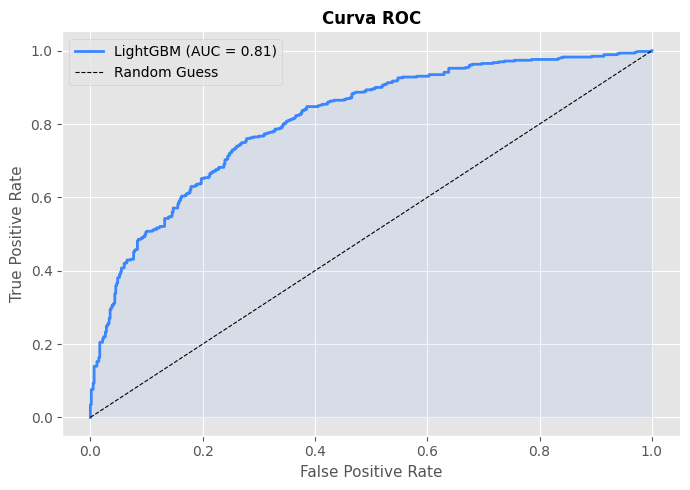

In [41]:
ROC_Curve_CM(y_test, y_prob_lgbm_opt, roc_auc_score(y_test, y_prob_lgbm_opt), 'LightGBM')

## 11. **Explicabilidad con DALEX**

Se utiliza la librería **DALEX** (*Descriptive mAchine Learning EXplanations*) para obtener una interpretación profunda y agnóstica del modelo:

- **Variable Importance** (permutación): importancia real medida por degradación del AUC al permutar cada feature.
- **Partial Dependence Plots (PDP)**: efecto marginal promedio de cada variable sobre la probabilidad predicha.
- **Break-down**: explicación a nivel de cliente individual (candidato a fidelización y a retención).

In [32]:
# Se preparan los datos para DALEX - se usa el mejor modelo tras Optuna (LightGBM)
X_test_feats = X_test[BEST_FEATS].copy()

explainer = dx.Explainer(
    model=best_pipe_opt,
    data=X_test_feats,
    y=y_test.values,
    label=BEST_OPT_NAME,
    predict_function=lambda m, d: m.predict_proba(d)[:, 1],
    verbose=False
)

print('Explainer creado correctamente.')
print(f'  Modelo: {BEST_OPT_NAME}  |  Observaciones: {len(X_test_feats)}  |  Features: {list(BEST_FEATS)}')

Explainer creado correctamente.
  Modelo: LightGBM  |  Observaciones: 1056  |  Features: ['avg_days_between_orders', 'recency', 'frequency', 'monetary', 'n_products', 'customer_age_days', 'n_countries']


### 11.1. **Variable Importance por permutación**

In [33]:
vi = explainer.model_parts(loss_function='1-auc', N=None, B=10, random_state=42)
vi.plot(title=f'Variable Importance (permutación) - {BEST_OPT_NAME}',
        bar_width=16)

***Observaciones***:

El análisis de importancia por permutación revela que el modelo LightGBM basa su capacidad predictiva principalmente en `recency` (pérdida de +0.107), seguida del promedio de días entre pedidos y el valor monetario. 

Esto valida que el comportamiento temporal reciente es el factor determinante para la recompra, mientras que variables geográficas (`n_countries`) carecen de impacto significativo en este contexto.

### 11.2. **Partial Dependence Plots (PDP)**

Calculating ceteris paribus:   0%|          | 0/1 [00:00<?, ?it/s]

Calculating ceteris paribus: 100%|██████████| 1/1 [00:00<00:00,  6.86it/s]


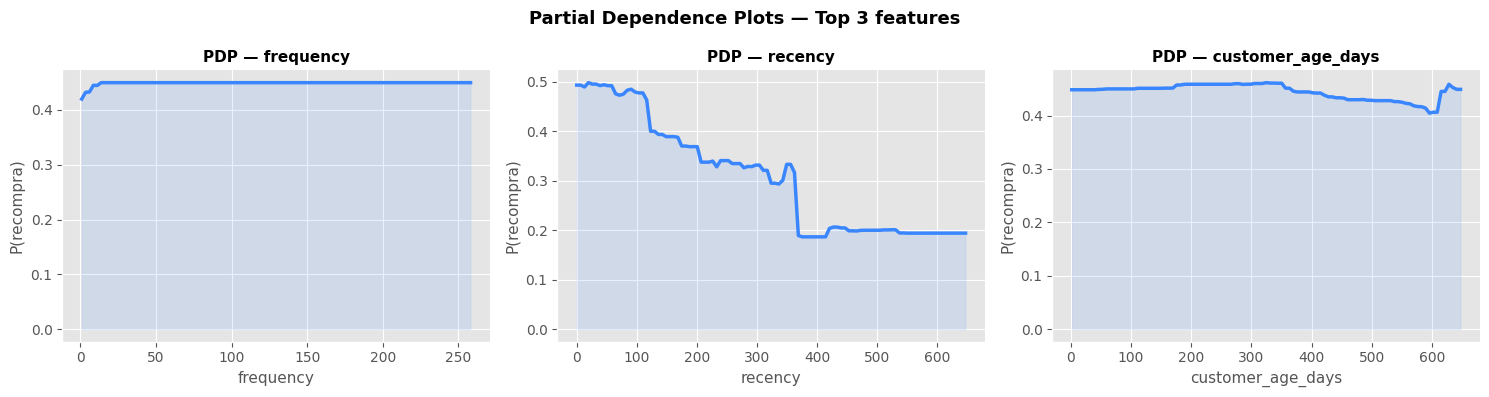

In [34]:
# PDP para las 3 features más importantes (según ranking de importancia)
top3 = top_features[:3]

pdps = [explainer.model_profile(variables=[feat], N=300, random_state=42) for feat in top3]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, pdp, feat in zip(axes, pdps, top3):
    pdp_df = pdp.result
    ax.plot(pdp_df['_x_'], pdp_df['_yhat_'], color=C_BLUE, linewidth=2.5)
    ax.fill_between(pdp_df['_x_'], pdp_df['_yhat_'], alpha=0.12, color=C_BLUE)
    ax.set_xlabel(feat, fontsize=11)
    ax.set_ylabel('P(recompra)', fontsize=11)
    ax.set_title(f'PDP — {feat}', fontsize=11, fontweight='bold')
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('Partial Dependence Plots — Top 3 features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


***Observaciones***:

Los **perfiles de dependencia** confirman que `recency` es el driver principal, identificando umbrales críticos de riesgo a los 120 y 370 días de inactividad. Asimismo, se observa un efecto de saturación en `frequency`, donde el incremento de probabilidad de recompra se estanca tras los primeros 15 pedidos, sugiriendo que el comportamiento de lealtad se consolida tempranamente.

### 11.3. **Explicación individual - Break-down**

In [35]:
# Se calcula probabilidades con el modelo optimizado
y_prob_opt_full = best_pipe_opt.predict_proba(X_test_feats)[:, 1]
idx_high = y_prob_opt_full.argmax()
idx_low  = y_prob_opt_full.argmin()

print(f'Cliente candidato a FIDELIZACIÓN  (P={y_prob_opt_full[idx_high]:.3f}): índice {idx_high}')
print(f'Cliente candidato a RETENCIÓN      (P={y_prob_opt_full[idx_low]:.3f}):  índice {idx_low}')
print()
print('Perfil cliente fidelización:')
print(X_test_feats.iloc[[idx_high]].to_string())
print()
print('Perfil cliente retención:')
print(X_test_feats.iloc[[idx_low]].to_string())

Cliente candidato a FIDELIZACIÓN  (P=0.950): índice 462
Cliente candidato a RETENCIÓN      (P=0.059):  índice 817

Perfil cliente fidelización:
      avg_days_between_orders  recency  frequency  monetary  n_products  customer_age_days  n_countries
2173                  27.5217        3         24 8775.0200         428                633            1

Perfil cliente retención:
      avg_days_between_orders  recency  frequency  monetary  n_products  customer_age_days  n_countries
1341                 598.0000      378          2  332.4400          20                598            1


In [36]:
# Break-down - Cliente de alta probabilidad (candidato a fidelización)
bd_high = explainer.predict_parts(
    X_test_feats.iloc[[idx_high]],
    type='break_down'
)
bd_high.plot(title=f'Break-down — Cliente fidelización  (P={y_prob_opt_full[idx_high]:.3f})')

In [37]:
# Break-down - Cliente de baja probabilidad (candidato a retención)
bd_low = explainer.predict_parts(
    X_test_feats.iloc[[idx_low]],
    type='break_down'
)
bd_low.plot(title=f'Break-down — Cliente retención  (P={y_prob_opt_full[idx_low]:.3f})')

***Observaciones***:

El **Break-down** permite validar la lógica del modelo LightGBM. 

Mientras que en el perfil de fidelización el hábito de compra constante (baja latencia entre pedidos) dispara la probabilidad al 95%, en el perfil de retención la inactividad prolongada (>370 días) y la falta de recurrencia actúan como los principales detractores, reduciendo la probabilidad de recompra a un 5.9%. Estos hallazgos permiten diseñar estrategias de marketing hiper-segmentadas: recompensas para el primero y campañas de rescate agresivas para el segundo

## 12. **Resumen y conclusiones**

### Resultados del proceso completo

| Fase | Modelo | AUC CV | AUC Test |
|---|---|---|---|
| Baseline | Logistic Regression | 0.7972 | 0.8075 |
| Mejor CV (pre-Optuna) | Logistic Regression | 0.7985 | 0.8075 |
| Post-Optuna | LightGBM | 0.8012| 0.8103 |

###### La optimización con Optuna permitió al modelo LightGBM extraer patrones complejos de los datos, logrando una mejora neta de +0.03 en el AUC de test frente a su versión base.


### Conclusiones de negocio

1. **`recency`** es el predictor número uno. Existe una ventana crítica de 120 días; si el cliente no vuelve a comprar en ese periodo, la probabilidad de recompra cae drásticamente.

    - *Acción*: Automatizar *campañas de recuperación* antes de superar los 4 meses de inactividad.

2. El **análisis PDP** de **`frequency`** muestra que la probabilidad de recompra se estabiliza a partir de los 15 pedidos.

    - *Acción*: Centrar los esfuerzos de marketing en convertir a los clientes de "2-5 pedidos" en clientes de "+15 pedidos", ya que a partir de ahí la lealtad es orgánica y estable.

3. Para la empresa es más rentable identificar al 85% de los posibles compradores (aunque enviemos alguna promoción de más) que ser muy estrictos y perder casi al 40% de los clientes fieles por falta de impacto.

4. Gracias al análisis Break-down, se sabe que un cliente con más de 370 días de inactividad y una baja cadencia de pedidos tiene menos de un 6% de probabilidad de volver.

    - *Acción*: Estos clientes requieren ofertas agresivas o, en su defecto, menor inversión publicitaria dada su baja probabilidad de retorno.

### Siguientes pasos

- Implementar el modelo como API de scoring periódico (semanal/mensual).
- Definir un experimento A/B para medir el uplift real de la segmentación ML vs. reglas de negocio tradicionales.
- Incorporar features adicionales (categoría de producto, canal de compra) en un ciclo iterativo.